# Assignment 2
In the previous workbook, we had a classifier which was designed to classify two specific different digits, one that we called **signal** and the other we called **background**.   

In this assignment, we will want to read in all of the digits, and design a classifier which again classifies a specific digit (our **signal** again), but this time **all** of the other 9 digits will serve as the background.   Our background will naturally be 9 times bigger than our signal (unless we limit it).

## Tasks 
1.   You will need to **shuffle** or randomize the rows of the background data (so that we mix different digits).   I will provide code for reading the digits in, but they will be in ordered batches of the same digit.   To shuffle these so they are no longer in order, google **sklearn shuffle pandas**.
2.   Come up with a method to limit the rows of the background data that you use, so that it is the **same length** (in rows) as the signal dataframe.   You will want some easy way to turn this on and off.   Run first with the background limited to the **same** length as the signal.
3.   After step 1, you will have a signal dataframe, and a randomized background dataframe.   You will need to combine these two into a single dataframe.  We did this in the inclass module, so you can look at that, or you can look at **pandas concat** function.   Use the name **dfCombined** for the combined dataframe.
4.   Next you will want to apply an estimator to this dataset. Copy the (final) calc_performance method from the inclass module, and run it for both the training and testing results for your estimator. 
Using the tablulate method display the following for training and testing:
        - precision
        - recall
        - f1_score
        - auc
            
5. Plot on the same graph the ROC curve for test and train data for the above estimator.

6. Run with a different classifier (and the large background statistics): the SGDClassifier.  Compare your results to the LinearSVC classifier by doing the following:
    - using the print_table method display the following for the two estimators:
        - precision
        - recall
        - f1_score
        - auc
    - Plot on the same graph the ROC curve for test data for the two estimators.
         

## Needed for good plotly-express behavior

In [22]:
import plotly.io as pio
pio.renderers.default='notebook+pdf'

# Getting the data:
As usual the data is in the project space.   If you uncomment the line with **short = "short_"**, the code will run faster.  

Once it is working you **must** use the full sample.

Use **short =""** for submission.

In [23]:
import pandas as pd
#
# Use "short=short_" for testing or if you don't have much memory

# Change it to short = "" for submission!!

#short = ""
short = "short_"

#
# Read in all of the other digits
dfAll = pd.DataFrame()
for digit in range(10):
    print("Processing digit ",digit)
    fname = '/fs/ess/PAS2038/PHYSICS_5680_OSU/class_data/module2/digit_' + short + str(digit) + '.csv'
    df = pd.read_csv(fname,header=None)
    df['digit'] = digit
    dfAll = pd.concat([dfAll, df])
print(dfAll.head())

Processing digit  0
Processing digit  1
Processing digit  2
Processing digit  3
Processing digit  4
Processing digit  5
Processing digit  6
Processing digit  7
Processing digit  8
Processing digit  9
   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   783  digit  
0    0      0  
1    0      0  
2    0      0  
3    0      0  
4    0      0  

[5 rows x 785 columns]


# Defining Signal
At the top of this block we define which of the 10 digits we want to use for our **signal**.

In [24]:
#
# Define our "signal" digit
digitSignal = 5
#
# This is the signal digiot
dfA = dfAll[dfAll['digit']==digitSignal].copy()

#
# ALL of the OTHER digits are background
dfB = dfAll[dfAll['digit']!=digitSignal].copy()


dfA['signal'] = 1
dfB['signal'] = 0

print("Length of signal sample:     ",len(dfA))
print("Length of background sample: ",len(dfB))
print(dfA.head())

Length of signal sample:      1000
Length of background sample:  9000
   0  1  2  3  4  5  6  7  8  9  ...  776  777  778  779  780  781  782  783  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   digit  signal  
0      5       1  
1      5       1  
2      5       1  
3      5       1  
4      5       1  

[5 rows x 786 columns]


# Task 1: Shuffle background
You will need to **shuffle** or randomize the rows of the background data.  We already read the digits in, but they were in batches of the the same digit.   So we need to shuffle them to mix the digits up.  To figure out how to do this, use google gemini:

```
I have a dataframe called dfB.  I want to shuffle it and have the output called dfBShuffle.  Can you show me how to do this?
```

Note that the "shuffle" method from sklearn creates copies of the orginal dataframe.

In [25]:
# Shuffle the data here
# Use dfBShuffle (or simething similar) as the name of the shuffled dataframe
from sklearn.utils import shuffle
dfBShuffle = shuffle(dfB, random_state=42)

# Task 2: Limit background
Come up with a method (use google!) to limit the rows of the background data that you use, so that it is the **same length** (in rows) as the signal dataframe.   You will want some easy way to turn this on and off.   Run first with the background limited to the **same** length as the signal.   Later you can come back and use all of the background data.

Again using gemini:
```
I have a signal dataframe called dfA, and another called dfBShuffle.  I want to limit the size of dfBShuffle to the same size as dfA.  I want the new dataframe to be called dfB_use.   Can you help me do this?
```



In [26]:
# Your code goes here
#
# Uncomment the next line to limit dfB to be the same length as dfA
dfB_use = dfBShuffle.head(len(dfA))
#
# Put your code here you get from gemini (appropriately modified if necessary) to limit dfB_use to the same size as dfA

# Task 3: Combining data
After steps 1 and 2 , you will have a signal dataframe, and a randomized background dataframe.   You will need to combine these two into a single dataframe.  We have done this before using the **pandas concat** function (see section "Obtaining the data" in the inclass module.  


Use the name **dfCombined** for the combined dataframe.


Make sure you **normalize** the features as we did in the inclass module.

In [27]:
import numpy as np
from sklearn.preprocessing import StandardScaler
# Concatenate dfA and dfb_Use
dfCombined = pd.concat([dfA, dfB_use])
#
# Make sure we normalize the features
features = dfCombined.drop(['digit', 'signal'], axis=1).columns
scaler = StandardScaler()
dfCombined[features] = scaler.fit_transform(dfCombined[features])

print("Size of signal sample ",len(dfA))
print("Size of background sample ",len(dfB_use))
print("Size of combined sample ",len(dfCombined))

Size of signal sample  1000
Size of background sample  1000
Size of combined sample  2000


In [28]:
# Combine the signal and background data
dfCombined = pd.concat([dfA, dfB_use], axis=0).reset_index(drop=True)

# Optional: Shuffle the combined dataframe (good for mixing signal and background)
from sklearn.utils import shuffle
dfCombined = shuffle(dfCombined, random_state=42).reset_index(drop=True)

# Check result
print("Combined DataFrame shape:", dfCombined.shape)
print(dfCombined['digit'].value_counts())  # Check class distribution

Combined DataFrame shape: (2000, 786)
digit
5    1000
1     130
8     125
7     114
6     113
2     113
4     111
0     103
9     101
3      90
Name: count, dtype: int64


#  Task 4: Apply the estimator and calculate performance results
Use SVC as the estimator.

Note we did all of this in the inclass workbook.
1. you will have to import a number of packages
2. you will want to copy the calc_performance method from the  inclass workbook (**use the last version from the END of the notebook!!**)
3. Then you can copy a big chunk from the "Everything from start to finish!" section of the inclass workbook
  - You will need to split the data into test/train subsets
  - train the classifier
  - apply the predict method to both test and train samples
  - test the performance of the classifier

Use the tabulate method to display the following for training and testing:
            - precision
            - recall
            - f1_score
            - auc

We have **some** of the code already written below.  Insert the missing code using the in-class notebook as an aid.

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from tabulate import tabulate
import time

labels = 'signal'
features = dfCombined.drop(['digit', 'signal'], axis=1).columns

def calc_performance(true_labels, pred_labels, scores=None):
    results = {}
    results['precision'] = precision_score(true_labels, pred_labels)
    results['recall']    = recall_score(true_labels, pred_labels)
    results['f1_score']  = f1_score(true_labels, pred_labels)
    if scores is not None:
        results['auc'] = roc_auc_score(true_labels, scores)

    cm = confusion_matrix(true_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Signal'])
    # disp.plot()   # Uncomment if you want to visualize confusion matrix
    return results, cm

#Training/testing split
df_train_digits, df_test_digits = train_test_split(dfCombined, test_size=0.2, random_state=42)
X_train, y_train = df_train_digits[features], df_train_digits[labels]
X_test,  y_test  = df_test_digits[features], df_test_digits[labels]

#Training the SVC estimator
t0 = time.time()
est = SVC(kernel='linear', C=1.0, random_state=42)
est.fit(X_train, y_train)

#Predictions and decision scores
y_train_pred  = est.predict(X_train)
y_test_pred   = est.predict(X_test)
y_train_score = est.decision_function(X_train)
y_test_score  = est.decision_function(X_test)

#Evaluating performance
result_train, cm_train = calc_performance(y_train, y_train_pred, y_train_score)
result_test,  cm_test  = calc_performance(y_test,  y_test_pred,  y_test_score)

# Printing metrics for test set
print()
print("Precision = ", round(result_test['precision'], 3))
print("Recall =    ", round(result_test['recall'],    3))
print("F1 score =  ", round(result_test['f1_score'],  3))
print("AUC =       ", round(result_test['auc'],       3))
print()
print("Esimtator:", est)
print("Total time:", round(time.time()-t0, 3), "s")



Precision =  0.891
Recall =     0.914
F1 score =   0.902
AUC =        0.962

Esimtator: SVC(kernel='linear', random_state=42)
Total time: 0.678 s


In [42]:
# Get our test and train data
df_train_digits,df_test_digits = train_test_split(dfCombined, test_size=0.2, random_state=42)
#

X_train = df_train_digits[features]
y_train = df_train_digits[labels]
X_test  = df_test_digits[features]
y_test  = df_test_digits[labels]

t0 = time.time()
est = SVC(kernel="linear", C=1.0, random_state=42)
est.fit(X_train, y_train)

y_train_pred = est.predict(X_train)
y_test_pred  = est.predict(X_test)

y_train_score = est.decision_function(X_train)
y_test_score  = est.decision_function(X_test)

result_train, cm_train = calc_performance(y_train, y_train_pred, y_train_score)
result_test,  cm_test  = calc_performance(y_test,  y_test_pred,  y_test_score)

print()
print("Precision = ",round(result_test['precision'],3))
print("Recall =    ",round(result_test['recall'],3))
print("F1 score =  ",round(result_test['f1_score'],3))
print("AUC =       ",round(result_test['auc'],3))
print()
print("Esimtator:",est)
print("Total time:",time.time()-t0)


Precision =  0.891
Recall =     0.914
F1 score =   0.902
AUC =        0.962

Esimtator: SVC(kernel='linear', random_state=42)
Total time: 0.6969692707061768


In [43]:
table = [
    [ "", "Train Sample", "Test Sample"],
    [ "Precision", round(result_train['precision'],3), round(result_test['precision'],3) ],
    [ "Recall", round(result_train['recall'],3), round(result_test['recall'],3) ],
    [ "F1", round(result_train['f1_score'],3), round(result_test['f1_score'],3) ],
    [ "AUC", round(result_train['auc'],3), round(result_test['auc'],3) ]
]
print_table_type='fancy_grid'
print_table = tabulate(table, headers='firstrow', tablefmt=print_table_type)

print(print_table)

╒═══════════╤════════════════╤═══════════════╕
│           │   Train Sample │   Test Sample │
╞═══════════╪════════════════╪═══════════════╡
│ Precision │              1 │         0.891 │
├───────────┼────────────────┼───────────────┤
│ Recall    │              1 │         0.914 │
├───────────┼────────────────┼───────────────┤
│ F1        │              1 │         0.902 │
├───────────┼────────────────┼───────────────┤
│ AUC       │              1 │         0.962 │
╘═══════════╧════════════════╧═══════════════╛


# Task 5: Plot the ROC curve for train and test

<Figure size 640x480 with 0 Axes>

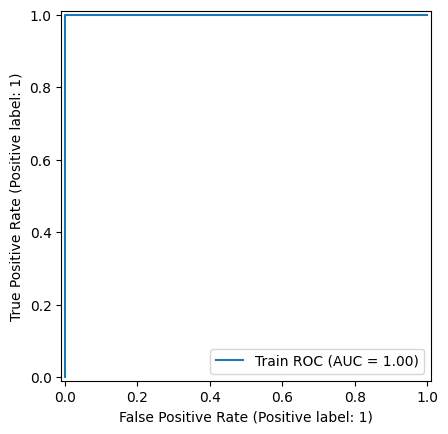

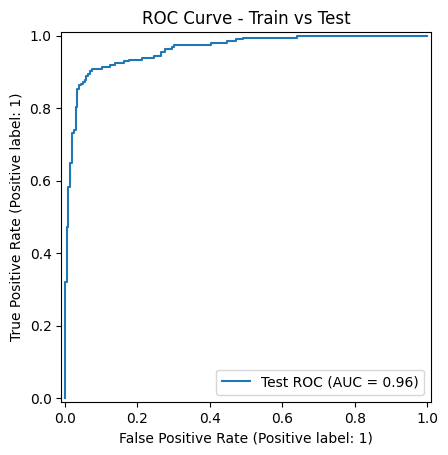

In [52]:
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure()
RocCurveDisplay.from_estimator(est, X_train, y_train, name="Train ROC")
RocCurveDisplay.from_estimator(est, X_test, y_test, name="Test ROC")
plt.title("ROC Curve - Train vs Test")
plt.show()

# Task 6: Try a different classifier
We will do the same as above, but use a different classifier called: SGDClassifier.

1. Use the tabulate method to display the following, comparing the SVC classifier to the SGDClassifier:
    - precision
    - recall
    - f1_score
    - auc

This should look like the table from task 4, except instead of "Train Sample" and "Test Sample", the columns should be "SGDClassifier Test Performance" and "SVC Test Performance"

2. Plot on the same graph the ROC curve for the **test** data, again comparing the SVC classifier to the SGDClassifier.

We start the code for you below.
         

In [47]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

#
# Define the estimator
estimator = SGDClassifier(random_state=42)
#estimator = SGDClassifier(random_state=42) ,class_weight="balanced") 

# Your code here
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train)

y_train_pred_sgd = sgd.predict(X_train)
y_test_pred_sgd  = sgd.predict(X_test)

y_train_score_sgd = sgd.decision_function(X_train)
y_test_score_sgd  = sgd.decision_function(X_test)

result_train_sgd, cm_train_sgd = calc_performance(y_train, y_train_pred_sgd, y_train_score_sgd)
result_test_sgd,  cm_test_sgd  = calc_performance(y_test,  y_test_pred_sgd,  y_test_score_sgd)

# NOTE this change!!!
#result_train_sgd = calc_performance(df_train_labels,y_train_pred,labels,y_train_score)
#
# Get resulst for test
#result_test_sgd = calc_performance(df_test_labels,y_test_pred,labels,y_test_score)

# MAKE SURE you change the confusion matrix and printout to reflect the new names above!!!

In [49]:
table = [
    [ "", "SGDClassifier Test Performance", "SVC Test Performance"],
    [ "Precision", round(result_test_sgd['precision'],3), round(result_test['precision'],3) ],
    [ "Recall", round(result_test_sgd['recall'],3), round(result_test['recall'],3) ],
    [ "F1", round(result_test_sgd['f1_score'],3), round(result_test['f1_score'],3) ],
    [ "AUC", round(result_test_sgd['auc'],3), round(result_test['auc'],3) ]
]
print_table_type='fancy_grid'
print_table = tabulate(table, headers='firstrow', tablefmt=print_table_type)
print(print_table)

╒═══════════╤══════════════════════════════════╤════════════════════════╕
│           │   SGDClassifier Test Performance │   SVC Test Performance │
╞═══════════╪══════════════════════════════════╪════════════════════════╡
│ Precision │                            0.949 │                  0.891 │
├───────────┼──────────────────────────────────┼────────────────────────┤
│ Recall    │                            0.858 │                  0.914 │
├───────────┼──────────────────────────────────┼────────────────────────┤
│ F1        │                            0.901 │                  0.902 │
├───────────┼──────────────────────────────────┼────────────────────────┤
│ AUC       │                            0.963 │                  0.962 │
╘═══════════╧══════════════════════════════════╧════════════════════════╛


<Figure size 640x480 with 0 Axes>

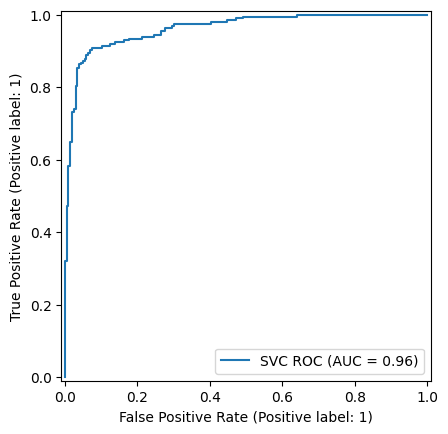

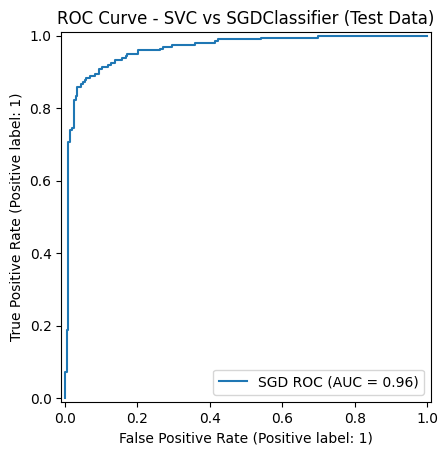

In [50]:
#
# Plot ROC Results here - compare SGD Test ROC to SVC Test ROC!!!!
plt.figure()
RocCurveDisplay.from_estimator(est, X_test, y_test, name="SVC ROC")
RocCurveDisplay.from_estimator(sgd, X_test, y_test, name="SGD ROC")
plt.title("ROC Curve - SVC vs SGDClassifier (Test Data)")
plt.show()


## Task 6A: Comment on the above ROC Curve
Give a 1-3 sentence comparison of the two ROC curves shown above.   Which of the two is the better classifier?

YOUR RESPONSE: Both the SVC and SGDClassifier achieve very similar ROC curves with an AUC of about 0.96, meaning they both classify signal vs. background effectively. The SVC curve is slightly smoother and more stable, so SVC can be considered the slightly better classifier here, though the difference is small.



## Extra Challenges: Some extra stuff: NOT REQUIRED FOR THE ASSIGNMENT

If you are looking for more to do!  This is not required as part of the assignment.


1. For a given signal digit, is the accuracy with which background is rejected dependent upon what the background digit is?   For example, given that our signal digit is 5, do you expect that the accuracy that an 8 is identifed as background the same as the accuracy that a 1 is identified as background?   Probably not!  To answer this:
    - Note that in training the above SVC classifier we had the signal digit as 5.    
    - When we ran our background through this classifier, the backgrounds were composed of digits 0,1,2,3,4,6,7,8,9 - all of the digits other than 5.  
    - Count how often each of the background digits is in the test sample and store this (using a defaultdict to store this count would be a good idea!), and also how often each of those digits were correctly classified as background (using a separate defaultdict to store this count would also be a good idea!).
    - Take the ratio of these two and you get the "accuracy" to reject the background as a function of the background digits.
    - Use the 1st Markdown box below to comment on your result.   Does it make sense which background digits have the lowest accuracy?

2. Impact of less data: Limit the signal to 100 total samples, and the total background to the same number. (So signal and background have equal size)  Compare the performance of the estimator with this small dataset to that of the full dataset using AUC.  Use SVC for the estimator.
     - Use the 2nd Markdown box below to comment on your result.   Does the change in AUC make sense?


## Your Code for Extra Challenge 1 follows:

Rank the above by accuracy

## Extra Challenge 1A: Comment on background Accuracies.
Give a 1-3 sentence answer to this question:  Does it make sense which background digits have the lowest accuracy?

YOUR RESPONSE: 



## Your Code for Extra Challenge 2 follows:

## Extra Challenge 2A: Comment on above the impact of less data
Give a 1-3 sentence answer to this question:  Does the change in AUC for the samll dataset compared to the full dataset make sense?

YOUR RESPONSE: 
